# 1.Background

For discussion, refer to:
https://www.kaggle.com/competitions/vesuvius-challenge-surface-detection/discussion/664320  

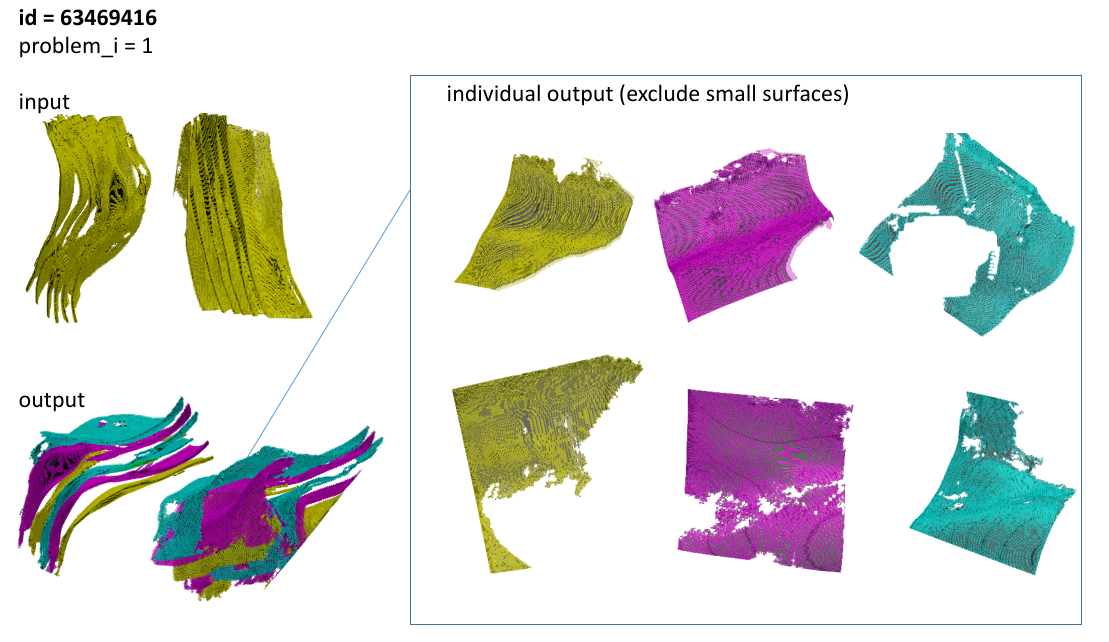

# 2.Code and Usage

In [ ]:
#pip and import
try:
    #import FastGeodis
    import cc3d
    import dijkstra3d
except:
    !pip install dijkstra3d
    !pip install connected-components-3d

# it is tiring to transfer local code to kaggle public notebook ... 
# kaggle or someone could provide an AI agent for this



import math
import numpy as np
import torch

import sys
sys.path.append('/kaggle/input/vesuvius-surface-marching-ants')
from process_helper import *


# a very slow replacement for 3d pyvista surface viewer

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
 
 
def show_in_3d(data, cmap="tab20", title=None, elev=30, azim=120):
    vol = data[::2,::2,::2] # already thresholded and labelled 
    #too slow so we subsmple
    
    # boolean mask of voxels to draw
    #vol = vol[:10]
    max_label = vol.max()

    # auto generate colors
    color = plt.cm.tab20(np.linspace(0, 1, max_label+1))

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    facecolors = np.zeros(vol.shape + (4,), dtype=float)
    for label in range(1,max_label+1):
        filled = vol==label
        facecolors[filled, :4] = color[label-1]    # RGBA tuple
        facecolors[filled,  3] = 0.6

    
    ax.voxels(vol!=0, facecolors=facecolors, edgecolor='none')
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect([s for s in vol.shape])  # equal aspect
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.tight_layout()
    plt.show()


In [ ]:
#main iterative split function
dump_dir='/kaggle/input/vesuvius-surface-marching-ants/dump'

SPLIT_ALL_MAX_DEPTH=50
def split_all_surface(problem, result, depth=0, max_depth=SPLIT_ALL_MAX_DEPTH):
    def collecting_and_return():
        #show_in_3d(problem, cmap='my_color', title='solved problem')
        result.append(problem)
        return
    #------------------------------

    print('spliting at depth', depth)
    if depth >= max_depth:
        return collecting_and_return()

    is_multi_surface, found = find_different_surface_seed(
        problem,
        iou_threshold=RAYCAST_IOU,
    )
    if not is_multi_surface:
        return  collecting_and_return()

    print('is_multi_surface', is_multi_surface)
    print('found:')
    print('\tz:', found['z'])
    print('\tpoint1_yx:', len(found['point1_yx']))
    print('\tpoint2_yx:', len(found['point2_yx']))

    point1_zyx = add_z(found['point1_yx'], found['z'][2])
    point2_zyx = add_z(found['point2_yx'], found['z'][2])
    s, solved = split_problem_to_two(
        problem,
        point1_zyx,
        point2_zyx,
        is_dilate=True
    )
    if not s:
        return  collecting_and_return()

    split_all_surface(solved==1, result, depth + 1, max_depth)
    split_all_surface(solved==2, result, depth + 1, max_depth)

    
#example usage
def do_demo(
    id, problem_id
):

    #id = 63469416 #11630450
    npz = np.load(f'{dump_dir}/{id}-out.npz')
    prob = npz['arr_0']   #unet voxel label results
    trurth = npz['arr_1'] #ground truth
    ignore = npz['arr_2'] #unlabelled region: true/false
    print('prob', prob.shape)
    
    prob1= prob.copy()
    prob1[ignore]=0  #for simplicity we ignore unlabelled region

    
    thresh1 = prob1>0.3
    cc1 = cc3d.connected_components(thresh1)
    stats1 = cc3d.statistics(cc1)
    print('stats1', stats1['voxel_counts'])
    
    print('cc1.max()', cc1.max())
    #show_in_3d(cc1,cmap='my_color',title='cc1')
    
    #############################################################
    i = problem_id# specific problem
    
    (zs, ys, xs) = stats1['bounding_boxes'][i]
    z1, z2 = zs.start, zs.stop
    y1, y2 = ys.start, ys.stop
    x1, x2 = xs.start, xs.stop
    print('z1, z2', z1, z2)
    
    problem = (cc1==i)[z1:z2, y1:y2, x1:x2]
    show_in_3d(problem,cmap='my_color',title='problem')
    
 
    solved = []
    split_all_surface(problem, solved, depth=0, max_depth=50)
    
    print('')
    print('****************************************************')
    print('split_all_surface', len(solved))
    
    overlay3d=np.zeros_like(problem, dtype=np.uint8)
    for i,s in enumerate(solved):
        print('adding:',i, s.sum())
        overlay3d[s!=0]=i+1

        #show one by one
        #show_in_3d(s.astype(np.uint8)*(i+1), cmap='my_color', title='s')
    
    #show all
    show_in_3d(overlay3d, cmap='my_color', title='solved', elev=30, azim=120)
    show_in_3d(overlay3d, cmap='my_color', title='solved', elev=60, azim=120)


#results are from a better-trained UNET model: 
#   https://www.kaggle.com/code/hengck23/demo-limit-of-good-unet-pixel-predict

#this is a simple case where 3 surfaces are stuck together
id = 11630450
problem_i =4

do_demo(id, problem_i)

# 2.to be updated ...
- others axamples
- how to adjust parameters
- limitations